#**Product: Amazon Alexa**


## **Assignment Natural Language processsing - Sentiment Analysis**

### **Customer Review Classification using Random Forest**

- Dataset consists of 3000 Amazon customer reviews, star ratings, date of review, variant and feedback of various amazon Alexa products like Alexa Echo, Echo dots.
- **The objective is to discover insights into consumer reviews and perfrom sentiment analysis on the data.** Positive or Negative review?
- Dataset: www.kaggle.com/sid321axn/amazon-alexa-reviews also provided(`amazon_alexa.tsv`)
---




### **Follow the instructions and complete each TODO to complete the assessment on the essential steps in building and evaluating a classification model.**



**Dataset Information:**

The dataset consists of customer reviews for Amazon Alexa products, including various features related to the product variation, customer rating, and feedback sentiment.

_Features/Columns_:
* rating: The customer rating of the product (scale of 1 to 5).
* date: The date when the review was posted.
* variation: The variation or type of Alexa product the review is for (e.g., "Charcoal Fabric", "Walnut Finish").
* verified_reviews: The actual review text written by the customer.
* feedback: The target variable indicating the sentiment of the review (1 for positive sentiment and 0 for negative sentiment).



---




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Number of rows and columns: (3150, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   rating            3150 non-null   int64 
 1   date              3150 non-null   object
 2   variation         3150 non-null   object
 3   verified_reviews  3149 non-null   object
 4   feedback          3150 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 123.2+ KB


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


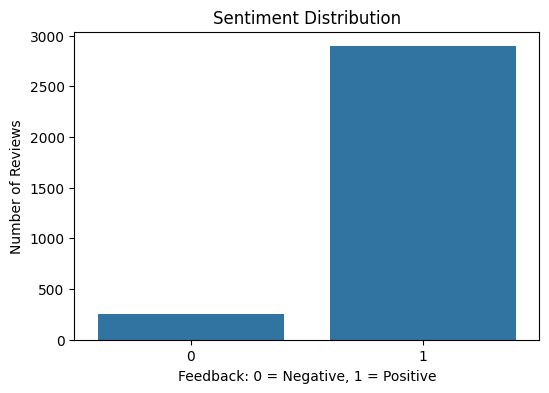

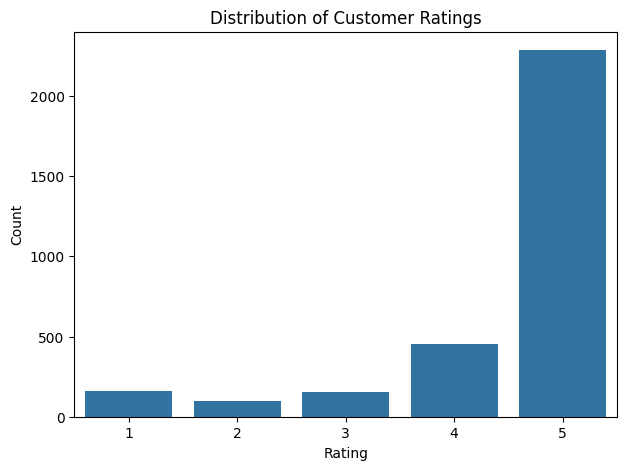

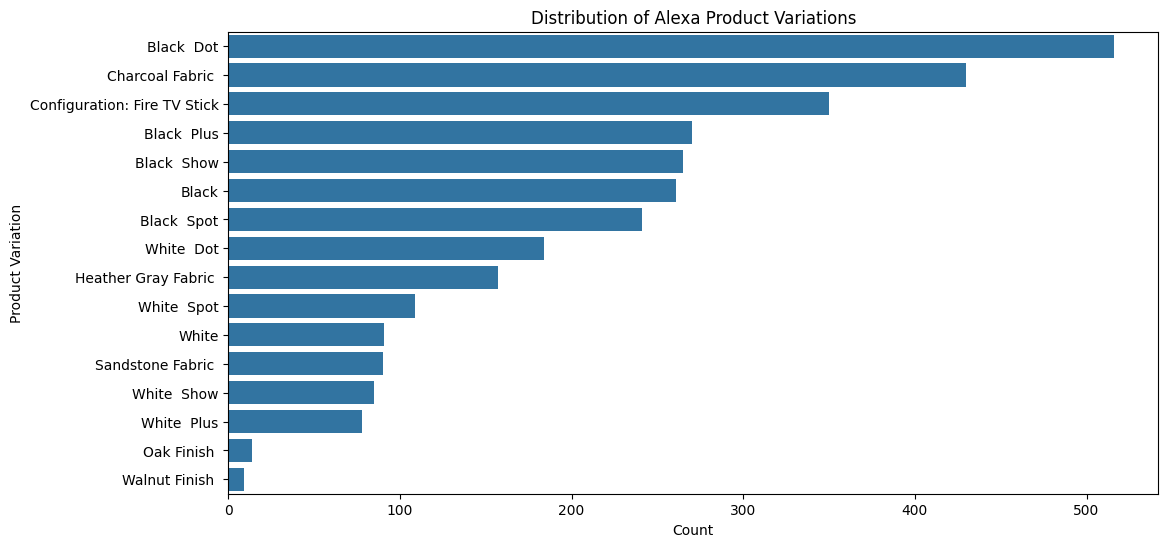

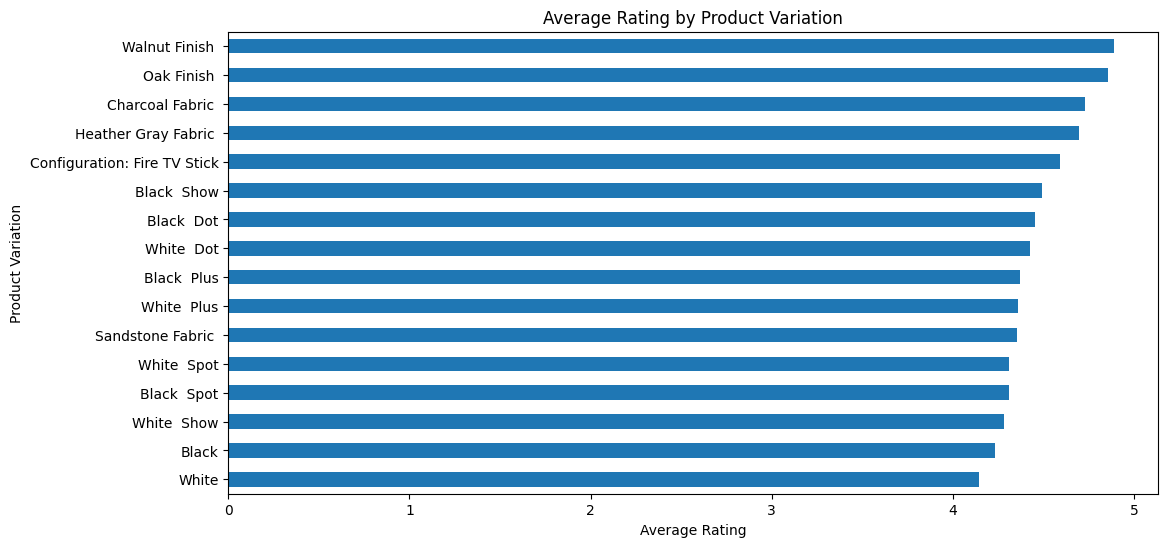

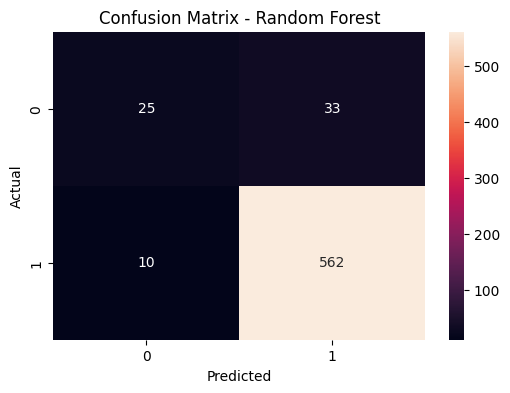

              precision    recall  f1-score   support

           0       0.71      0.43      0.54        58
           1       0.94      0.98      0.96       572

    accuracy                           0.93       630
   macro avg       0.83      0.71      0.75       630
weighted avg       0.92      0.93      0.92       630

Accuracy: 0.9317460317460318


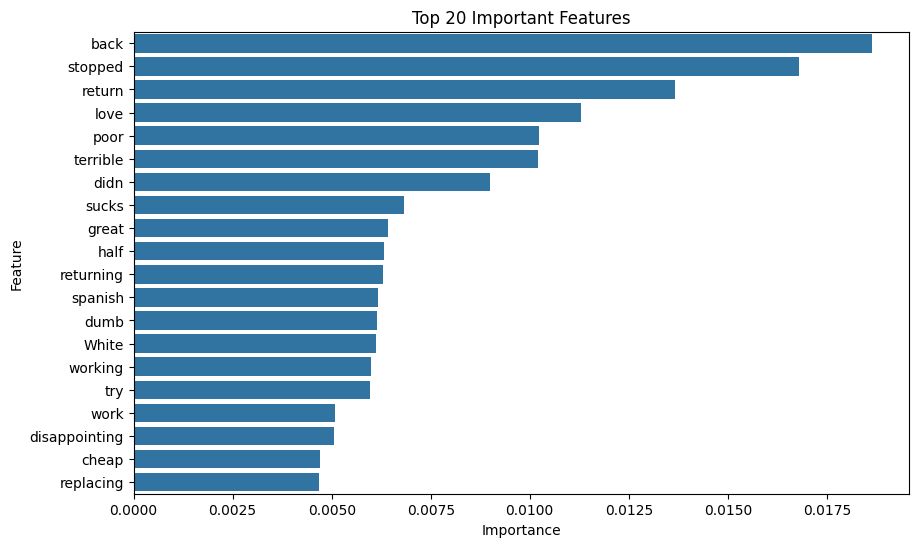

The sentiment of the new review is: Positive
Logistic Regression Results
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        58
           1       0.91      1.00      0.95       572

    accuracy                           0.91       630
   macro avg       0.45      0.50      0.48       630
weighted avg       0.82      0.91      0.86       630

Accuracy: 0.9079365079365079
Support Vector Machine Results
              precision    recall  f1-score   support

           0       0.88      0.40      0.55        58
           1       0.94      0.99      0.97       572

    accuracy                           0.94       630
   macro avg       0.91      0.70      0.76       630
weighted avg       0.94      0.94      0.93       630

Accuracy: 0.9396825396825397
Best Parameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}

Best Cross-Validation Accuracy:
0.9365079365079365


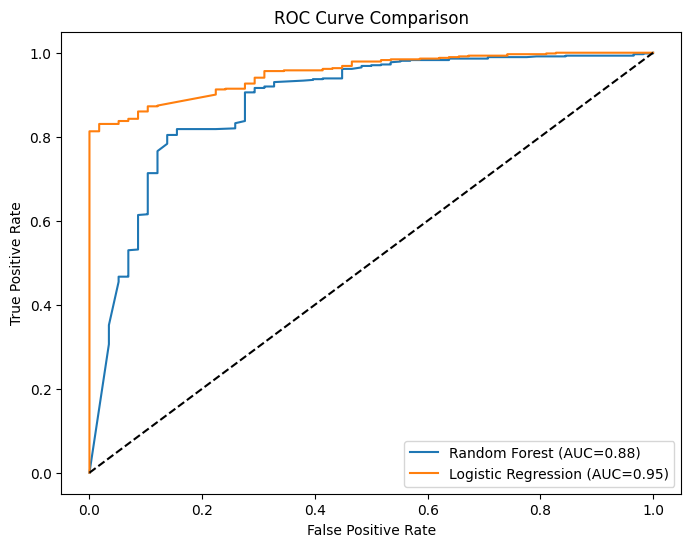

In [6]:
# Amazon Alexa Customer Review Sentiment Analysis
# Objective: Classify reviews as positive or negative using Random Forest




# TODO: Import necessary libraries
# Hint: You'll need pandas, numpy, matplotlib, seaborn, and various sklearn modules

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# TODO: Load the dataset
# Hint: Use pandas to read the CSV file from your Google Drive
# Import libraries
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import re
import string

from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

import warnings
warnings.filterwarnings("ignore")

nltk.download('stopwords')

# Load the Amazon Alexa Reviews dataset
df = pd.read_csv("amazon_alexa.tsv", sep="\t")

# Display first five rows
df.head()

print("Number of rows and columns:", df.shape)

#Dataset information
df.info()

#Missing values
df.isnull().sum()

#Summary statistics
df.describe(include='all')

# Data Visualization and Clean Up
# TODO: Visualize the distribution of feedback
# Hint: Use seaborn's countplot function

plt.figure(figsize=(6,4))
sns.countplot(x="feedback", data=df)
plt.title("Sentiment Distribution")
plt.xlabel("Feedback: 0 = Negative, 1 = Positive")
plt.ylabel("Number of Reviews")
plt.show()


# TODO: Visualize the relationship between variations and ratings
# Hint: Use seaborn's barplot function

plt.figure(figsize=(7,5))
sns.countplot(x="rating", data=df)
plt.title("Distribution of Customer Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()


plt.figure(figsize=(12,6))
sns.countplot(y="variation", data=df, order=df["variation"].value_counts().index)
plt.title("Distribution of Alexa Product Variations")
plt.xlabel("Count")
plt.ylabel("Product Variation")
plt.show()

plt.figure(figsize=(12,6))
avg_rating = df.groupby("variation")["rating"].mean().sort_values()
avg_rating.plot(kind="barh")
plt.title("Average Rating by Product Variation")
plt.xlabel("Average Rating")
plt.ylabel("Product Variation")
plt.show()

# TODO: Drop irrelevant columns
# Hint: Use the drop() method to remove 'date' and 'rating' columns

df_model = df.drop(["date", "rating"], axis=1)

# One-Hot Encoding
# TODO: Perform one-hot encoding on the 'variation' column
# Hint: Use pandas get_dummies() function

variation_dummies = pd.get_dummies(df_model["variation"], drop_first=True)

# Tokenization (Count Vectorizer)
# TODO: Tokenize the 'verified_reviews' column
# Hint: Use CountVectorizer from sklearn.feature_extraction.text

stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = " ".join(word for word in text.split() if word not in stop_words)
    return text

df_model["clean_review"] = df_model["verified_reviews"].apply(clean_text)


# Tokenization using CountVectorizer
vectorizer = CountVectorizer(max_features=2500)
review_vectors = vectorizer.fit_transform(df_model["clean_review"])

review_df = pd.DataFrame(
    review_vectors.toarray(),
    columns=vectorizer.get_feature_names_out()
)

# TODO: Combine tokenized reviews with the main dataframe
# Hint: Use pd.concat() to join the dataframes

# Combine tokenized reviews with one-hot encoded variation
X = pd.concat([review_df, variation_dummies.reset_index(drop=True)], axis=1)
y = df_model["feedback"]

# Prepare data for modeling
# TODO: Split the data into features (X) and target (y)
# Hint: The target variable is 'feedback'

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# TODO: Split the data into training and testing sets
# Hint: Use train_test_split from sklearn.model_selection

# Train the Random Forest model
# TODO: Create and train the Random Forest model
# Hint: Use RandomForestClassifier from sklearn.ensemble

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
# Evaluate the model
# TODO: Generate predictions and create confusion matrix
# Hint: Use the predict() method and confusion_matrix from sklearn.metrics
y_pred = rf_model.predict(X_test)
# TODO: Plot confusion matrix
# Hint: Use seaborn's heatmap function
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# TODO: Print classification report
# Hint: Use classification_report from sklearn.metrics
print(classification_report(y_test, y_pred))

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Feature Importance
# TODO: Visualize feature importance
# Hint: Access feature_importances_ attribute of the trained model

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False).head(20)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feature_importance)
plt.title("Top 20 Important Features")
plt.show()

# TODO: Make predictions on new data
# Hint: Create a function that takes a new review text, preprocesses it,
# and uses the trained model to predict its sentiment

def predict_sentiment(new_review):
    cleaned = clean_text(new_review)
    review_vector = vectorizer.transform([cleaned])
    review_vector_df = pd.DataFrame(
        review_vector.toarray(),
        columns=vectorizer.get_feature_names_out()
    )

    variation_zero = pd.DataFrame(
        np.zeros((1, variation_dummies.shape[1])),
        columns=variation_dummies.columns
    )

    final_input = pd.concat([review_vector_df, variation_zero], axis=1)
    prediction = rf_model.predict(final_input)[0]

    if prediction == 1:
        return "Positive"
    else:
        return "Negative"

# Example usage of your prediction function:
# new_review = "I love my Alexa device! It's so helpful."
# predicted_sentiment = predict_sentiment(new_review)
# print(f"The sentiment of the new review is: {predicted_sentiment}")

new_review = "I love my Alexa device! It's so helpful."
predicted_sentiment = predict_sentiment(new_review)
print(f"The sentiment of the new review is: {predicted_sentiment}")


# Compare Logistic Regression and SVM using TF-IDF

tfidf = TfidfVectorizer(max_features=5000)

X_tfidf = tfidf.fit_transform(df_model["clean_review"].fillna(""))
y = df_model["feedback"]

X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)

# Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)
lr_pred = lr_model.predict(X_test_tfidf)

print("Logistic Regression Results")
print(classification_report(y_test, lr_pred))
print("Accuracy:", accuracy_score(y_test, lr_pred))

# Support Vector Machine
svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train)
svm_pred = svm_model.predict(X_test_tfidf)

print("Support Vector Machine Results")
print(classification_report(y_test, svm_pred))
print("Accuracy:", accuracy_score(y_test, svm_pred))


# Hyperparameter tuning using GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(grid_search.best_score_)




from sklearn.metrics import roc_curve, auc

rf_prob = rf_model.predict_proba(X_test)[:,1]
lr_prob = lr_model.predict_proba(X_test_tfidf)[:,1]

rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)

rf_auc = auc(rf_fpr, rf_tpr)
lr_auc = auc(lr_fpr, lr_tpr)

plt.figure(figsize=(8,6))

plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC={rf_auc:.2f})")
plt.plot(lr_fpr, lr_tpr, label=f"Logistic Regression (AUC={lr_auc:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.show()


# Install transformers
!pip install transformers torch -q


In [7]:
from transformers import pipeline

# Load a pre-trained BERT sentiment analysis model
bert_classifier = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

# Test on sample reviews
reviews = [
    "I absolutely love my Alexa device!",
    "This is the worst product I have ever bought.",
    "The sound quality is amazing.",
    "I am disappointed with the performance."
]

for review in reviews:
    result = bert_classifier(review)
    print(f"Review: {review}")
    print(result)
    print("-" * 60)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Review: I absolutely love my Alexa device!
[{'label': 'POSITIVE', 'score': 0.999848484992981}]
------------------------------------------------------------
Review: This is the worst product I have ever bought.
[{'label': 'NEGATIVE', 'score': 0.9997852444648743}]
------------------------------------------------------------
Review: The sound quality is amazing.
[{'label': 'POSITIVE', 'score': 0.9998868703842163}]
------------------------------------------------------------
Review: I am disappointed with the performance.
[{'label': 'NEGATIVE', 'score': 0.9997972846031189}]
------------------------------------------------------------
